In [1]:
import numpy as np
import pandas as pd
import random
import re
import nltk
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, StratifiedKFold, GridSearchCV
from sklearn.metrics import f1_score, classification_report, confusion_matrix, roc_auc_score, brier_score_loss, fbeta_score, make_scorer
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import MultinomialNB
from sklearn.pipeline import Pipeline
from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.preprocessing import LabelEncoder

from gensim.models import Word2Vec

from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

nltk.download('stopwords')
nltk.download('wordnet')

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader, Subset
from torch.nn.utils.rnn import pad_sequence
from transformers import AutoTokenizer, AutoModel, get_linear_schedule_with_warmup
from torch.optim import AdamW
from collections import Counter
import time

import sys
import os

sys.path.append(os.path.abspath(os.path.join('..')))

torch.backends.cudnn.enabled = False
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)


[nltk_data] Downloading package stopwords to /home/alumno/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to /home/alumno/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!


In [2]:
%load_ext autoreload
%autoreload 2

from models import lstm, pretrained_transformer
from train import train_inference

In [3]:
df = pd.read_csv("../data/dataset_truncated.csv")

print(df['clase'].value_counts())

X = df['texto']
y = df['clase'] == 'susp'

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    stratify=y,
    random_state=SEED
)

clase
susp    60759
src     60592
Name: count, dtype: int64


In [4]:
stop_words = set(stopwords.words('english'))
lemmatizer = WordNetLemmatizer()

def clean_text(text):
    text = text.lower()
    text = re.sub(r"[^a-zA-Z\s]", "", text)
    tokens = text.split()
    tokens = [t for t in tokens if t not in stop_words]
    tokens = [lemmatizer.lemmatize(t) for t in tokens]
    return " ".join(tokens)

X_train_clean = X_train.apply(clean_text)
X_test_clean = X_test.apply(clean_text)


In [5]:
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)

In [6]:
def c_at_1(y_true, y_prob, threshold=0.5, uncertain_band=0.05):
    y_pred = np.full_like(y_true, -1)

    uncertain = np.abs(y_prob - threshold) <= uncertain_band
    y_pred[~uncertain] = (y_prob[~uncertain] >= threshold).astype(int)

    n = len(y_true)
    n_correct = np.sum(y_pred == y_true)
    n_unanswered = np.sum(uncertain)

    return (1/n) * (n_correct + n_unanswered * (n_correct/n))

In [7]:
def composite_metric(y_true, y_prob, **kwargs):
    y_prob = np.array(y_prob, dtype=float)

    if y_prob.ndim == 2:
        y_prob = y_prob[:, 1]

    y_pred = (y_prob >= 0.5).astype(int)

    roc = roc_auc_score(y_true, y_prob)
    brier = 1 - brier_score_loss(y_true, y_prob)
    f1 = f1_score(y_true, y_pred)
    f05u = fbeta_score(y_true, y_pred, beta=0.5)
    c1 = c_at_1(y_true, y_prob)

    return np.mean([roc, brier, f1, f05u, c1])


custom_scorer = make_scorer(
    composite_metric,
    needs_proba=True,
    greater_is_better=True
)

### Experiment 1

In [8]:
def build_vocab(texts, min_freq=2):
    counter = Counter()
    for text in texts:
        counter.update(text.split())

    vocab = {"<PAD>": 0, "<UNK>": 1}
    for word, freq in counter.items():
        if freq >= min_freq:
            vocab[word] = len(vocab)

    return vocab

vocab = build_vocab(X_train_clean)

In [9]:
from sklearn.model_selection import train_test_split

lstm_train_texts, lstm_val_texts, lstm_train_labels, lstm_val_labels = train_test_split(
    X_train_clean,
    y_train,
    test_size=0.2,
    stratify=y_train,
    random_state=SEED
)

In [10]:
lstm_train_dataset = lstm.LSTMDataset(lstm_train_texts, lstm_train_labels, vocab)
lstm_val_dataset = lstm.LSTMDataset(lstm_val_texts, lstm_val_labels, vocab)

train_loader = DataLoader(
    lstm_train_dataset,
    batch_size=8,
    shuffle=True,
    collate_fn=lstm.collate_lstm
)

val_loader = DataLoader(
    lstm_val_dataset,
    batch_size=8,
    collate_fn=lstm.collate_lstm
)

In [11]:
def count_parameters(model):
    return sum(
        p.numel() for p in model.parameters() if p.requires_grad
    )

In [12]:
model_lstm = lstm.LSTMClassifier(
    vocab_size=len(vocab),
    embedding_dim=100,
    hidden_dim=128,
    output_dim=2
)

model_lstm, val_score, training_time_lstm = train_inference.train_model(
    model_lstm,
    train_loader,
    val_loader,
    lr=1e-3,
    metric = composite_metric
)

In [13]:
test_dataset = lstm.LSTMDataset(X_test_clean, y_test, vocab)

test_loader = DataLoader(
    test_dataset,
    batch_size=8,
    collate_fn=lstm.collate_lstm
)

start = time.time()
test_metric = train_inference.evaluate_model(model_lstm, test_loader, composite_metric)
inference_time_lstm = time.time() - start
params = count_parameters(model_lstm)
gpu_memory = torch.cuda.max_memory_allocated() if torch.cuda.is_available() else 0

In [14]:
print(f"Train Score: {val_score}")
print(f"Test Score: {test_metric}")
print(f"Training time: {training_time_lstm}")
print(f"Inference time: {inference_time_lstm}")
print(f"Model params: {params}")
print(f"GPU Memory: {gpu_memory}")

Train Score: 0.8419272201327199
Test Score: 0.8381724953513396
Training time: 2130.5057899951935
Inference time: 41.09725522994995
Model params: 19421234
GPU Memory: 409736704


In [15]:
tokenizer = AutoTokenizer.from_pretrained("bert-base-uncased")

In [16]:
bert_train_dataset = pretrained_transformer.BERTDataset(X_train, y_train, tokenizer)
bert_test_dataset = pretrained_transformer.BERTDataset(X_test, y_test, tokenizer)

In [17]:
train_loader = DataLoader(
    bert_train_dataset,
    batch_size=8,
    shuffle=True
)

val_loader = train_loader
test_loader = DataLoader(
    bert_test_dataset,
    batch_size=8
)

In [18]:
model_bert = pretrained_transformer.TransformerClassifier(
    model_name="bert-base-uncased",
    output_dim=2,
    pooling="cls",
    freeze_encoder=False
)

2026-03-04 09:16:52.555570: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-03-04 09:16:52.621297: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F AVX512_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2026-03-04 09:16:53.856311: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.


In [19]:
model_bert, val_score, training_time_bert = train_inference.train_model(
    model_bert,
    train_loader,
    val_loader,
    metric = composite_metric,
    lr=2e-5,
    scheduler=True
)

In [20]:
start = time.time()

test_metric = train_inference.evaluate_model(model_bert, test_loader, composite_metric)

inference_time_bert = time.time() - start

params = count_parameters(model_bert)

gpu_memory = torch.cuda.max_memory_allocated() if torch.cuda.is_available() else 0

In [21]:
print(f"Train Score: {val_score}")
print(f"Test Score: {test_metric}")
print(f"Training time: {training_time_bert}")
print(f"Inference time: {inference_time_bert}")
print(f"Model params: {params}")
print(f"GPU Memory: {gpu_memory}")

Train Score: 0.9036533124274445
Test Score: 0.828137444157397
Training time: 9825.335600852966
Inference time: 225.9042627811432
Model params: 109483778
GPU Memory: 4145058816


In [22]:
tokenized = [text.split() for text in X_train_clean]

w2v_model = Word2Vec(
    sentences=tokenized,
    vector_size=100,
    window=5,
    min_count=2,
    workers=4,
    seed=SEED
)


In [23]:
class W2VVectorizer(BaseEstimator, TransformerMixin):
    def __init__(self, model):
        self.model = model
        self.dim = model.vector_size

    def fit(self, X, y=None):
        return self

    def transform(self, X):
        vectors = []
        for text in X:
            words = text.split()
            word_vecs = [self.model.wv[w] for w in words if w in self.model.wv]
            if len(word_vecs) == 0:
                vectors.append(np.zeros(self.dim))
            else:
                vectors.append(np.mean(word_vecs, axis=0))
        return np.array(vectors)


In [24]:
w2v_vectorizer = W2VVectorizer(w2v_model)

X_train_w2v = w2v_vectorizer.transform(X_train_clean)
X_test_w2v = w2v_vectorizer.transform(X_test_clean)

clf = LogisticRegression(max_iter=1000, random_state=SEED)

param_grid = {
    "C": [0.01, 0.1, 1, 10]
}

grid_w2v = GridSearchCV(
    clf,
    param_grid,
    cv=skf,
    scoring=custom_scorer,
    n_jobs=-1
)

grid_w2v.fit(X_train_w2v, y_train)

print("Best W2V Score:", grid_w2v.best_score_)


Best W2V Score: 0.7724851655638967


In [25]:
grid_w2v.best_params_

{'C': 0.01}

In [26]:
best_w2v = grid_w2v.best_estimator_
y_pred_w2v = best_w2v.predict(X_test_w2v)

print("Dense Test Score:",
      composite_metric(y_test, y_pred_w2v, average="macro"))

Dense Test Score: 0.7737869822641665


### Experiment 2

In [27]:
fractions = [0.25, 0.50, 0.75, 1.0]
lc_results = {
    "BASE": [],
    "LSTM": [],
    "BERT": []
}

   [BASE] Score: 0.7943
   [LSTM] Score: 0.8022
   [BERT] Score: 0.8195
   [BASE] Score: 0.8050
   [LSTM] Score: 0.8328
   [BERT] Score: 0.8332
   [BASE] Score: 0.8076
   [LSTM] Score: 0.8360
   [BERT] Score: 0.8332
   [BASE] Score: 0.8102
   [LSTM] Score: 0.8339
   [BERT] Score: 0.8324


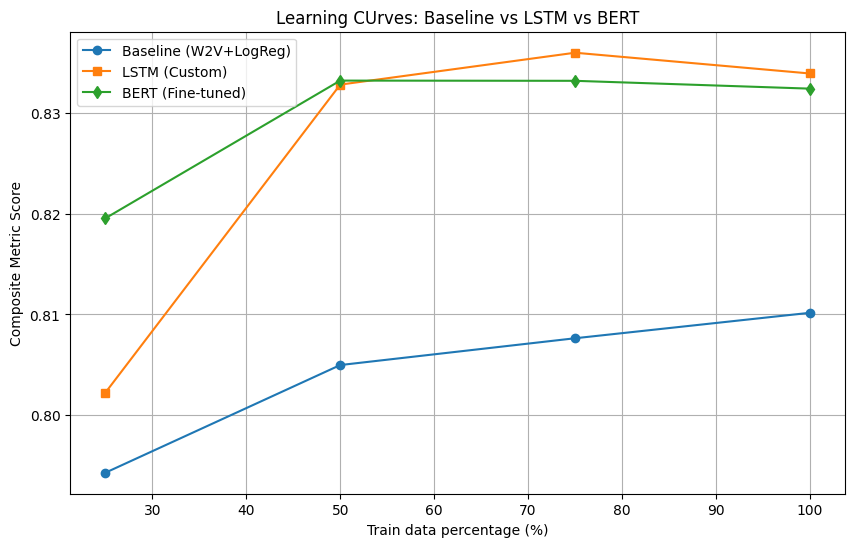

In [28]:
test_dataset_lstm = lstm.LSTMDataset(X_test_clean, y_test, vocab)
test_loader_lstm = DataLoader(test_dataset_lstm, batch_size=16, collate_fn=lstm.collate_lstm)

test_dataset_bert = pretrained_transformer.BERTDataset(X_test, y_test, tokenizer)
test_loader_bert = DataLoader(test_dataset_bert, batch_size=16)


for frac in fractions:
    
    X_sub_indices = X_train.sample(frac=frac, random_state=SEED).index
    y_sub = y_train.loc[X_sub_indices]

    X_sub_clean = X_train_clean.loc[X_sub_indices]
    
    tokenized_sub = [text.split() for text in X_sub_clean]
    w2v_model_sub = Word2Vec(sentences=tokenized_sub, vector_size=100, window=5, min_count=1, workers=4, seed=SEED)
    
    v_sub = W2VVectorizer(w2v_model_sub)
    X_train_w2v = v_sub.transform(X_sub_clean)
    X_test_w2v = v_sub.transform(X_test_clean) 
    
    clf = LogisticRegression(max_iter=1000, random_state=SEED, C=1.0)
    clf.fit(X_train_w2v, y_sub)
    y_pred_base = clf.predict_proba(X_test_w2v) 
    
    score_base = composite_metric(y_test, y_pred_base)
    lc_results["BASE"].append(score_base)
    print(f"   [BASE] Score: {score_base:.4f}")


    ds_lstm = lstm.LSTMDataset(X_sub_clean, y_sub, vocab)
    ld_lstm = DataLoader(ds_lstm, batch_size=8, shuffle=True, collate_fn=lstm.collate_lstm)

    model_l = lstm.LSTMClassifier(vocab_size=len(vocab), embedding_dim=100, hidden_dim=128, output_dim=2)
    
    model_l, _, _ = train_inference.train_model(
        model_l, ld_lstm, ld_lstm, 
        metric=composite_metric, lr=1e-3 
    )
    
    score_lstm = train_inference.evaluate_model(model_l, test_loader_lstm, metric=composite_metric)
    lc_results["LSTM"].append(score_lstm)
    print(f"   [LSTM] Score: {score_lstm:.4f}")

    X_sub_raw = X_train.loc[X_sub_indices]
    ds_bert = pretrained_transformer.BERTDataset(X_sub_raw, y_sub, tokenizer)
    ld_bert = DataLoader(ds_bert, batch_size=8, shuffle=True)

    model_b = pretrained_transformer.TransformerClassifier(
        model_name="bert-base-uncased", output_dim=2, freeze_encoder=False
    )

    model_b, _, _ = train_inference.train_model(
        model_b, ld_bert, ld_bert, 
        metric=composite_metric, 
        lr=2e-5,   
        scheduler=True  
    )
    
    score_bert = train_inference.evaluate_model(model_b, test_loader_bert, metric=composite_metric)
    lc_results["BERT"].append(score_bert)
    print(f"   [BERT] Score: {score_bert:.4f}")

plt.figure(figsize=(10, 6))
plt.plot([f*100 for f in fractions], lc_results["BASE"], 'o-', label="Baseline (W2V+LogReg)")
plt.plot([f*100 for f in fractions], lc_results["LSTM"], 's-', label="LSTM (Custom)")
plt.plot([f*100 for f in fractions], lc_results["BERT"], 'd-', label="BERT (Fine-tuned)")
plt.xlabel("Train data percentage (%)")
plt.ylabel("Composite Metric Score")
plt.title("Learning CUrves: Baseline vs LSTM vs BERT")
plt.legend()
plt.grid(True)
plt.show()

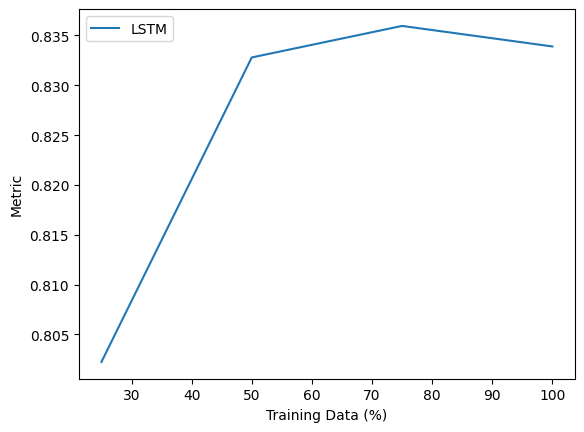

In [29]:
plt.plot([25,50,75,100], lc_results["LSTM"], label="LSTM")
plt.xlabel("Training Data (%)")
plt.ylabel("Metric")
plt.legend()
plt.show()

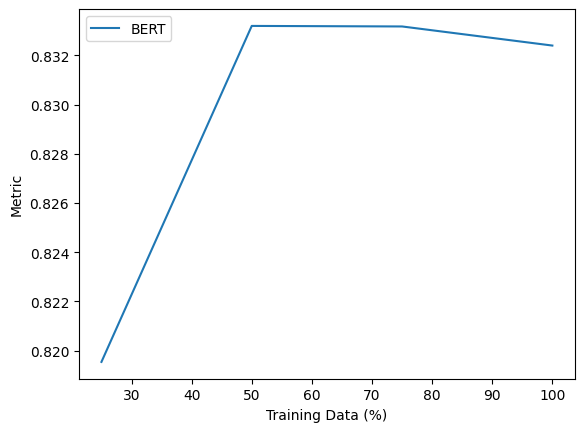

In [30]:
plt.plot([25,50,75,100], lc_results["BERT"], label="BERT")
plt.xlabel("Training Data (%)")
plt.ylabel("Metric")
plt.legend()
plt.show()

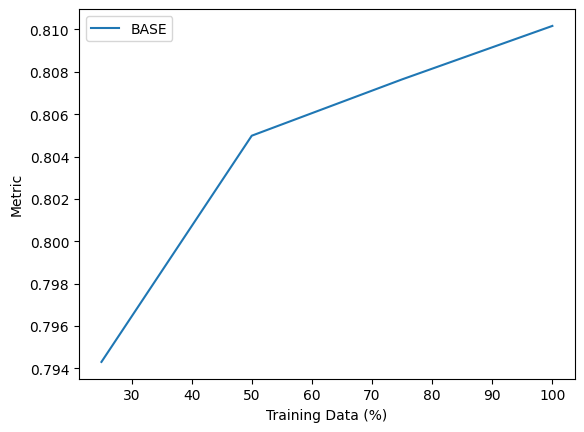

In [31]:
plt.plot([25,50,75,100], lc_results["BASE"], label="BASE")
plt.xlabel("Training Data (%)")
plt.ylabel("Metric")
plt.legend()
plt.show()

### Experiment 3

In [32]:
lstm_train_loader = DataLoader(
    lstm_train_dataset, 
    batch_size=8, 
    shuffle=True, 
    collate_fn=lstm.collate_lstm
)
lstm_val_loader = DataLoader(
    lstm_val_dataset, 
    batch_size=8, 
    collate_fn=lstm.collate_lstm
)

print("\nAblation 1: LSTM Bidirectionality")
configs_lstm = [False, True]
ablation_lstm_results = {}

for is_bidirectional in configs_lstm:
    model_ab = lstm.LSTMClassifier(
        vocab_size=len(vocab), 
        embedding_dim=100, 
        hidden_dim=128, 
        output_dim=2, 
        bidirectional=is_bidirectional
    )
    
    _, val_score, _ = train_inference.train_model(
        model_ab, 
        lstm_train_loader, 
        lstm_val_loader, 
        metric=composite_metric, 
        lr=1e-3
    )
    ablation_lstm_results[f"Bidirectional={is_bidirectional}"] = val_score

bert_train_loader = DataLoader(bert_train_dataset, batch_size=8, shuffle=True)
bert_val_loader = bert_train_loader 

print("\nAblation 2: BERT Frozen vs Fine-tuned")
configs_bert = [True, False] 
ablation_bert_results = {}

for freeze in configs_bert:
    print(f"Training BERT - Frozen: {freeze}")
    model_ab = pretrained_transformer.TransformerClassifier(
        "bert-base-uncased", 
        output_dim=2, 
        freeze_encoder=freeze
    )
    
    _, val_score, _ = train_inference.train_model(
        model_ab, 
        bert_train_loader, 
        bert_val_loader, 
        metric=composite_metric, 
        lr=2e-5 
    )
    ablation_bert_results[f"Frozen={freeze}"] = val_score

print("\n--- SUMMARY ---")
print("LSTM results:", ablation_lstm_results)
print("BERT results:", ablation_bert_results)


Ablation 1: LSTM Bidirectionality

Ablation 2: BERT Frozen vs Fine-tuned
Training BERT - Frozen: True
Training BERT - Frozen: False

--- SUMMARY ---
LSTM results: {'Bidirectional=False': 0.8338685827032165, 'Bidirectional=True': 0.834584683173933}
BERT results: {'Frozen=True': 0.745343624746313, 'Frozen=False': 0.9071014454386088}


### Experiment 4

In [33]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model_bert.to(device)

y_pred_base = best_w2v.predict(X_test_w2v) 

bert_test_dataset = pretrained_transformer.BERTDataset(X_test, y_test, tokenizer)
bert_test_loader = DataLoader(bert_test_dataset, batch_size=8)

y_pred_neural = [] 
model_bert.eval()

with torch.no_grad():
    for batch in bert_test_loader:
        input_ids = batch['input_ids'].to(device)
        attention_mask = batch['attention_mask'].to(device)
        
        outputs = model_bert(input_ids, attention_mask)
        preds = torch.argmax(outputs, dim=1)
        y_pred_neural.extend(preds.cpu().numpy())

y_pred_neural = np.array(y_pred_neural)
test_df = pd.DataFrame({'text': X_test, 'target': y_test, 'base': y_pred_base, 'neural': y_pred_neural})

fixed_by_neural = test_df[(test_df['base'] != test_df['target']) & (test_df['neural'] == test_df['target'])].head(5)

new_errors = test_df[(test_df['base'] == test_df['target']) & (test_df['neural'] != test_df['target'])].head(5)

print("--- Fixed examples by Neural ---")
print(fixed_by_neural['text'].values)

print("\n--- New introduced errors by Neural ---")
print(new_errors['text'].values)

--- Fixed examples by Neural ---
['Pricing Variable Annuity Contracts with High-Water Mark Feature By V. M. Belyaev Abstract Variable annuities (VA) are popular insurance products. VAs provides the insured with a guaranteed accumulation rate on their premium at maturity. In addition, the insured may receive extra benefit if returns of underlying funds are high enough. Here we consider a special case of VA with high-water mark feature and Guaranteed Minimum payment reset. In Black-Scholes model for underlying fund we derive explicit pricing formula for this type of contract. The value of VA contracts depends on the time between observation dates. Corrections due to this effect are calculated and compared with Monte-Carlo results. Good agreement between analytical formula and numerical calculations of VA values is demonstrated. 1 Introduction Variable annuity (VA) contract provides the policyholder with a guaranteed minimum return and offers extra benefit if returns of underlying funds a

### Experiment 5

In [34]:
import torch
import time

def get_inference_metrics(model, loader):
    device = next(model.parameters()).device
    model.eval()
    
    start = time.time()
    with torch.no_grad():
        for batch in loader:
            if isinstance(batch, dict):
                input_ids = batch['input_ids'].to(device)
                
                if 'attention_mask' in batch:
                    mask = batch['attention_mask'].to(device)
                    _ = model(input_ids, mask)
                else:
                    _ = model(input_ids)
            
            else:
                inputs = batch[0].to(device)
                _ = model(inputs)
                
    end = time.time()
    return end - start

lstm_test_dataset = lstm.LSTMDataset(X_test_clean, y_test, vocab)
lstm_test_loader = DataLoader(
    lstm_test_dataset, 
    batch_size=8, 
    collate_fn=lstm.collate_lstm
)

bert_test_dataset = pretrained_transformer.BERTDataset(X_test, y_test, tokenizer)
bert_test_loader = DataLoader(
    bert_test_dataset, 
    batch_size=8
)


inf_time_bert = get_inference_metrics(model_bert, bert_test_loader) 
inf_time_lstm = get_inference_metrics(model_lstm, lstm_test_loader) 

comp_data = {
    "Model": ["LogReg+W2V", "LSTM", "BERT"],
    "Params": [
        "~10K", 
        f"{count_parameters(model_lstm):,}", 
        f"{count_parameters(model_bert):,}"
    ],
    "Train Time (s)": [
        "< 10s", 
        f"{training_time_lstm:.2f}", 
        f"{training_time_bert:.2f}"
    ],
    "Inference Speed (ex/s)": [
        "Very High", 
        f"{len(y_test)/inf_time_lstm:.2f}", 
        f"{len(y_test)/inf_time_bert:.2f}"
    ],
    "GPU Memory (MB)": [
        "0", 
        "~450MB", 
        "~3500MB" 
    ]
}

df_comp = pd.DataFrame(comp_data)
print("\n=== Análisis Computacional ===")
print(df_comp)

if not os.path.exists("../results"): os.makedirs("../results")
df_comp.to_csv("../results/computational_analysis.csv", index=False)


=== Análisis Computacional ===
        Model       Params Train Time (s) Inference Speed (ex/s)  \
0  LogReg+W2V         ~10K          < 10s              Very High   
1        LSTM   19,421,234        2130.51                 534.52   
2        BERT  109,483,778        9825.34                 143.65   

  GPU Memory (MB)  
0               0  
1          ~450MB  
2         ~3500MB  
